### Configure Project Root Path

In [32]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

### Environment Setup and Imports

In [33]:
# Imports and Reproducibility

# Core libraries
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sparse matrix tools
from scipy.sparse import coo_matrix, csr_matrix

# Project modules
from src.sparse_matrix import build_sparse_matrix
from src.data_split import train_test_split_sparse
from src.data_loader import load_movielens_data, preprocess_movielens, save_dataset

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)


#### Movielens folder directory

In [34]:
# Figure directories
figures_dir = Path("../figures")

movielens_fig_dir = figures_dir / "movielens"
comparison_fig_dir = figures_dir / "comparison"

# Results directories
results_dir = Path("../results")

movielens_results_dir = results_dir / "movielens"
comparison_results_dir = results_dir / "comparison"

# Create folders if they do not exist
for folder in [
    movielens_fig_dir,
    comparison_fig_dir,
    movielens_results_dir,
    comparison_results_dir
]:
    folder.mkdir(parents=True, exist_ok=True)

### Data Loading and Preprocessing

In [35]:
# Load and Preprocess MovieLens Data

data_dir = "../data/movielens"

# Load raw datasets
user_rating_history, ratings_additional, movies = load_movielens_data(data_dir)

# Preprocess and merge datasets
final_dataset = preprocess_movielens(
    user_rating_history,
    ratings_additional,
    movies
)

# Basic validation checks
print("First 5 rows:")
print(final_dataset.head())

print("\nDataset shape:")
print(final_dataset.shape)

print("\nColumns:")
print(final_dataset.columns)

print("\nMissing values:")
print(final_dataset.isnull().sum())

# Save cleaned dataset
output_path = Path("../data/movielens/movielens_final_dataset.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

save_dataset(final_dataset, output_path)

print("\nDataset saved successfully.")

First 5 rows:
   userId  movieId  rating              tstamp                                      title                          genres
0   50449     1407     4.0 1997-09-15 16:09:20                              Scream (1996)  Comedy|Horror|Mystery|Thriller
1   50449      260     5.0 1997-09-15 16:11:57  Star Wars: Episode IV - A New Hope (1977)         Action|Adventure|Sci-Fi
2   50449       36     4.0 1997-09-15 16:12:45                    Dead Man Walking (1995)                     Crime|Drama
3   50449      800     4.0 1997-09-15 16:13:16                           Lone Star (1996)           Drama|Mystery|Western
4   50449       32     4.0 1997-09-15 16:13:53  Twelve Monkeys (a.k.a. 12 Monkeys) (1995)         Mystery|Sci-Fi|Thriller

Dataset shape:
(5178319, 6)

Columns:
Index(['userId', 'movieId', 'rating', 'tstamp', 'title', 'genres'], dtype='object')

Missing values:
userId        0
movieId       0
rating        0
tstamp        0
title      1067
genres     3932
dtype: int64

Data

#### Data Summary (MovieLens)

The MovieLens dataset contains 5,178,319 observations and 6 variables: userId, movieId, rating, tstamp, title, and genres. The dataset includes no missing values in the core variables required for recommendation modeling, namely user identifiers, movie identifiers, ratings, and timestamps, ensuring reliable construction of the sparse user-item interaction matrix. A small number of missing values are present in the metadata variables, with 1,067 missing movie titles and 3,932 missing genre entries. Since the recommendation models primarily rely on user-item rating interactions rather than movie metadata, these missing values do not significantly affect the matrix factorization and optimization process. The dataset is large-scale and highly sparse, making it well-suited for evaluating recommender system models and optimization strategies.

### Building the Sparse Matrix

In [36]:
# Load Processed Dataset and Build Sparse Matrix

final_dataset = pd.read_csv(
    "../data/movielens/movielens_final_dataset.csv",
    parse_dates=["tstamp"]
)

# Build sparse user–movie matrix
R_csr, user_map, movie_map = build_sparse_matrix(final_dataset)

# Matrix dimensions
num_users, num_movies = R_csr.shape
num_ratings = R_csr.nnz

print(f"Matrix shape: {R_csr.shape}")
print(f"Number of users: {num_users}")
print(f"Number of movies: {num_movies}")
print(f"Observed ratings: {num_ratings}")

# Sparsity calculation
density = num_ratings / (num_users * num_movies)
print(f"Matrix density: {density:.6f}")

Matrix shape: (16876, 81848)
Number of users: 16876
Number of movies: 81848
Observed ratings: 5178319
Matrix density: 0.003749


#### Sparse Matrix Summary

The processed MovieLens dataset was transformed into a sparse user–movie interaction matrix of size 16,876×81,848, representing the relationships between users and movies. The matrix contains 5,178,319 observed ratings corresponding to known user–item interactions. Despite the large number of observed ratings, the matrix density is approximately 0.003749 (0.3749%), indicating that the vast majority of possible user–movie interactions are unobserved. This high level of sparsity presents a fundamental challenge for recommendation systems, as the models must learn meaningful latent relationships from only a small fraction of the full interaction space. The sparse structure of the MovieLens dataset contrasts strongly with dense datasets such as MNIST and motivates the use of matrix factorization and specialized optimization strategies for recommender system modeling.

### Interaction-level random split

In [37]:
# Train-Test Split for Sparse MovieLens Matrix

# Split sparse matrix into training and test sets using observed ratings
R_train, R_test = train_test_split_sparse(
    R_csr,
    test_size=0.2,
    seed=SEED
)

# Basic split information
print("Train nnz:", R_train.nnz)
print("Test nnz:", R_test.nnz)

# Density of each matrix
train_density = R_train.nnz / (R_train.shape[0] * R_train.shape[1])
test_density = R_test.nnz / (R_test.shape[0] * R_test.shape[1])

print(f"Train density: {train_density:.6f}")
print(f"Test density: {test_density:.6f}")

# Check that train + test equals original observed ratings
total_nnz = R_train.nnz + R_test.nnz
print("Split correct:", total_nnz == R_csr.nnz)

# Check actual split ratio
train_ratio = R_train.nnz / R_csr.nnz
test_ratio = R_test.nnz / R_csr.nnz

print(f"Train ratio: {train_ratio:.3f}")
print(f"Test ratio: {test_ratio:.3f}")

# Confirm matrix shapes are preserved
print("Original shape:", R_csr.shape)
print("Train shape:", R_train.shape)
print("Test shape:", R_test.shape)

Train nnz: 4142656
Test nnz: 1035663
Train density: 0.002999
Test density: 0.000750
Split correct: True
Train ratio: 0.800
Test ratio: 0.200
Original shape: (16876, 81848)
Train shape: (16876, 81848)
Test shape: (16876, 81848)


#### Train–Test Split Summary

The user–movie interaction matrix was partitioned into training and test sets using an 80/20 split on the observed ratings. The training matrix contains 4,142,656 nonzero entries, while the test matrix contains 1,035,663 entries, preserving all observed user–item interactions from the original dataset. Both matrices retain the original dimensions of 16,876×81,848, ensuring consistent user and movie representation across training and evaluation stages.

The resulting matrix densities are approximately 0.002999 for the training set and 0.000750 for the test set, further highlighting the highly sparse nature of the recommendation data. The split proportions match the intended ratios, with 80% of the observed ratings allocated to training and 20% reserved for testing, while validation checks confirm that the split was performed correctly without loss of data. This partitioning strategy provides a realistic recommendation setting in which models learn from partially observed interactions and are evaluated on their ability to predict unseen ratings.

### Sample the dataset to use for faster performance

In [38]:
# Create Smaller MovieLens Sample for Faster Experiments

# Take 10% sample of observed ratings
final_dataset_small = final_dataset.sample(
    frac=0.10,
    random_state=SEED
).copy()

# Rebuild sparse user-movie matrix from sampled data
R_csr_small, user_map_small, movie_map_small = build_sparse_matrix(final_dataset_small)

# Split sampled sparse matrix into train/test sets
R_train_small, R_test_small = train_test_split_sparse(
    R_csr_small,
    test_size=0.2,
    seed=SEED
)

# Basic subset statistics
num_users_small, num_movies_small = R_csr_small.shape
num_ratings_small = R_csr_small.nnz
density_small = num_ratings_small / (num_users_small * num_movies_small)

print("Small dataset rows:", final_dataset_small.shape[0])
print("Small dataset columns:", final_dataset_small.shape[1])
print("Small matrix shape:", R_csr_small.shape)
print("Small users:", num_users_small)
print("Small movies:", num_movies_small)
print("Small nonzero entries:", num_ratings_small)
print(f"Small density: {density_small:.6f}")

# Train/test statistics
print("\nTrain nnz:", R_train_small.nnz)
print("Test nnz:", R_test_small.nnz)

train_density_small = R_train_small.nnz / (R_train_small.shape[0] * R_train_small.shape[1])
test_density_small = R_test_small.nnz / (R_test_small.shape[0] * R_test_small.shape[1])

print(f"Train density: {train_density_small:.6f}")
print(f"Test density: {test_density_small:.6f}")

# Split validation
print("\nSplit correct:", R_train_small.nnz + R_test_small.nnz == R_csr_small.nnz)
print(f"Train ratio: {R_train_small.nnz / R_csr_small.nnz:.3f}")
print(f"Test ratio: {R_test_small.nnz / R_csr_small.nnz:.3f}")

Small dataset rows: 517832
Small dataset columns: 6
Small matrix shape: (14167, 35310)
Small users: 14167
Small movies: 35310
Small nonzero entries: 517832
Small density: 0.001035

Train nnz: 414266
Test nnz: 103566
Train density: 0.000828
Test density: 0.000207

Split correct: True
Train ratio: 0.800
Test ratio: 0.200


#### Sampled Dataset Summary (10% Subset)

To improve computational efficiency during experimentation, a 10% subset of the MovieLens dataset was used, containing 517,832 observations and 6 variables. The sampled data was transformed into a sparse user–movie interaction matrix of size 14,167×35,310, with 517,832 observed user–item ratings. Despite the reduced dataset size, the matrix remains highly sparse, with a density of approximately 0.001035 (0.1035%), preserving the sparse structural characteristics of the original recommendation data.

The sampled interaction matrix was partitioned into training and test sets using an 80/20 split on the observed ratings. The training matrix contains 414,266 nonzero entries, while the test matrix contains 103,566 entries, with densities of approximately 0.000828 and 0.000207, respectively. Validation checks confirm that the split was performed correctly, preserving all observed interactions while maintaining the intended training and testing proportions. Both matrices retain identical dimensions, ensuring consistency in user and movie representation across training and evaluation.

The reduced dataset enables faster model training, optimization, and hyperparameter tuning while maintaining the large-scale sparse structure characteristic of recommendation systems. This allows efficient experimentation without substantially altering the underlying recommendation problem.

### Baseline Model: Matrix Factorization with SGD

In [39]:
# use smaller matrices for quick experiments

R_train = R_train_small
R_test = R_test_small

## Baseline Model

## Global Mean Predictor (GMP)

The Global Mean Predictor (GMP) is the simplest baseline model used in recommender systems. It predicts every user–movie rating using the average rating observed in the training data. The model is defined as: 
$\hat{r}_{ui} = \mu$ where $\hat{r}_{ui}$
represents the predicted rating and μ is the global average of all observed ratings in the dataset. The global mean is computed as: $
\mu = \frac{1}{N}\sum_{i=1}^{N} r_i
$
where N is the total number of observed ratings.

The GMP assumes that all users and movies behave similarly, meaning every prediction is assigned the same average rating regardless of user preferences or movie characteristics. Although the model is simple and does not capture personalization, it provides an important statistical reference point for evaluating recommendation systems.

In this study, the GMP serves as the baseline model for comparing matrix factorization methods optimized using SGD, Adam, and multilevel training strategies. Any effective recommendation model should achieve lower RMSE than the GMP, demonstrating that it successfully learns meaningful user–item interaction patterns beyond simple average behavior.

The GMP also forms the foundation of the biased matrix factorization framework used in this study. The full recommendation model extends the global mean by incorporating user biases, movie biases, and latent factor interactions: 
$$
\hat{r}_{ui} = \mu + b_u + b_i + P_u^T Q_i
$$

where $\mu$ is the global mean rating, 
$b_u$ is the user bias, 
$b_i$ is the movie bias, 
and $P_u^T Q_i$ represents the latent interaction between user and movie factors. This progression allows the model to move from simple global averages toward personalized recommendation learning.

## Matrix Factorization

Matrix Factorization (MF) is a collaborative filtering technique widely used in recommender systems to model user-item interactions. The main idea of matrix factorization is to approximate a sparse user-movie rating matrix using two lower-dimensional latent factor matrices representing users and movies. Instead of relying only on observed ratings, the method learns hidden latent representations that capture underlying preference patterns and movie characteristics. If $R \in \mathbb{R}^{m \times n}$ represents the user-movie rating matrix, matrix factorization approximates the matrix as:

$$
R \approx PQ^T
$$

where $P$ represents the user latent-factor matrix, $Q$ represents the movie latent-factor matrix, and $k$ denotes the number of latent dimensions.

In matrix factorization, each user and movie is represented by a latent vector in a lower-dimensional feature space. The predicted rating is computed using the dot product between the user and movie latent representations:

$$
\hat{r}_{ui} = P_u^T Q_i
$$

where $P_u$ represents the latent vector for user $u$ and $Q_i$ represents the latent vector for movie $i$. These latent factors capture hidden relationships such as movie genres, user interests, and rating tendencies that are not explicitly observed in the dataset. As a result, matrix factorization is capable of learning personalized recommendation patterns from sparse user--item interactions.

In this study, matrix factorization was extended using global mean, user bias, and movie bias components to improve predictive accuracy. The final recommendation model is defined as:

$$
\hat{r}_{ui} = \mu + b_u + b_i + P_u^T Q_i
$$

where $\mu$ is the global mean rating, $b_u$ is the user bias, $b_i$ is the movie bias, and $P_u^TQ_i$ represents the latent interaction between users and movies. This formulation allows the model to move beyond simple average behavior and learn personalized recommendation structures. Matrix factorization forms the core recommendation framework used throughout this research and was optimized using SGD, Adam, and multilevel optimization strategies to investigate convergence behavior, runtime performance, and predictive accuracy on sparse MovieLens data.

In [40]:
# MovieLens Reference Baseline and Matrix Factorization Model

# Convert train and test sparse matrices to COO format
# COO format gives direct access to observed user-movie-rating entries
R_train_coo = R_train.tocoo()
R_test_coo = R_test.tocoo()

# 1. Statistical Reference Baseline: Global Mean Predictor
#-------------------------------------------------------------------------
# This is not matrix factorization.
# It predicts every rating using the average rating from the training data.
# It provides a simple reference point before training matrix factorization.

global_mean = R_train_coo.data.mean()


def compute_global_mean_rmse(R_coo, prediction):
    preds = np.full_like(R_coo.data, prediction, dtype=float)
    errors = R_coo.data - preds
    return np.sqrt(np.mean(errors ** 2))


train_rmse_baseline = compute_global_mean_rmse(R_train_coo, global_mean)
test_rmse_baseline = compute_global_mean_rmse(R_test_coo, global_mean)

print("Statistical Reference Baseline: Global Mean Predictor")
print(f"Global mean rating: {global_mean:.4f}")
print(f"Baseline Train RMSE: {train_rmse_baseline:.4f}")
print(f"Baseline Test RMSE: {test_rmse_baseline:.4f}")


# 2. Main MovieLens Model: Matrix Factorization

# Base Model: Matrix Factorization Before Optimization
# ---------------------------------------------------------

# Candidate latent dimensions to examine
k_values = [5, 10, 20, 40]

# Regularization and planned training setting
reg = 0.1
n_epochs = 12

# Matrix dimensions
n_users, n_movies = R_train.shape

# RMSE function for matrix factorization
def compute_mf_rmse(R_coo, P, Q):
    preds = np.sum(P[R_coo.row] * Q[R_coo.col], axis=1)
    errors = R_coo.data - preds
    return np.sqrt(np.mean(errors ** 2))


base_model_results = []

for k in k_values:
    rng = np.random.default_rng(SEED)

    # Randomly initialize user and movie latent factors
    P_base = 0.1 * rng.standard_normal((n_users, k))
    Q_base = 0.1 * rng.standard_normal((n_movies, k))

    # Evaluate before any optimization
    train_rmse = compute_mf_rmse(R_train_coo, P_base, Q_base)
    test_rmse = compute_mf_rmse(R_test_coo, P_base, Q_base)

    base_model_results.append({
        "Model": "Base Matrix Factorization",
        "k": k,
        "Train RMSE Before Optimization": train_rmse,
        "Test RMSE Before Optimization": test_rmse,
        "Regularization": reg,
        "Planned Epochs": n_epochs
    })

base_model_df = pd.DataFrame(base_model_results)

base_model_df

Statistical Reference Baseline: Global Mean Predictor
Global mean rating: 3.4472
Baseline Train RMSE: 1.0303
Baseline Test RMSE: 1.0355


,Model,k,Train RMSE Before Optimization,Test RMSE Before Optimization,Regularization,Planned Epochs
0,Base Matrix Factorization,5,3.597979,3.594109,0.1,12
1,Base Matrix Factorization,10,3.598021,3.594141,0.1,12
2,Base Matrix Factorization,20,3.598206,3.594352,0.1,12
3,Base Matrix Factorization,40,3.598365,3.594852,0.1,12


#### Baseline Model Summary

The Global Mean Predictor was implemented as a statistical reference baseline for evaluating recommendation performance. This model predicts every user–movie rating using the overall average rating from the training data, which is 3.4472. The baseline achieves a training RMSE of 1.0303 and a test RMSE of 1.0355, with the close agreement between these values indicating stable and consistent generalization between training and unseen data. However, because the model ignores individual user preferences and movie-specific characteristics, its predictive capability remains limited.

To establish a stronger recommendation framework, Matrix Factorization models were initialized using latent dimensions k=5,10,20, and 40. Before optimization, all configurations produce very high RMSE values near 3.59 on both the training and test sets, indicating that the randomly initialized latent factors have not yet learned meaningful user–item relationships. The similarity of RMSE values across different latent dimensions further shows that increasing model complexity alone does not improve predictive performance prior to training.

These results establish a clear baseline for subsequent optimization experiments using SGD and Adam. The large gap between the initial Matrix Factorization RMSE values and the Global Mean Predictor benchmark highlights the importance of optimization in learning useful latent representations from sparse user–movie interactions.

### Optimizer Comparison: SGD vs Adam on Small Sample

#### Test best lr

In [41]:
# Quick Learning Rate Test Function

def quick_lr_test(optimizer, lr_list, epochs=8):
    results = []

    for lr in lr_list:
        rng = np.random.default_rng(SEED)

        P = 0.1 * rng.standard_normal((n_users, k))
        Q = 0.1 * rng.standard_normal((n_movies, k))

        if optimizer == "adam":
            mP = np.zeros_like(P)
            vP = np.zeros_like(P)
            mQ = np.zeros_like(Q)
            vQ = np.zeros_like(Q)
            beta1, beta2, eps = 0.9, 0.999, 1e-8
            t = 0

        for epoch in range(epochs):
            indices = rng.permutation(len(R_train_coo.data))

            for idx in indices:
                u = R_train_coo.row[idx]
                i = R_train_coo.col[idx]
                r_ui = R_train_coo.data[idx]

                pred = P[u] @ Q[i]
                err = r_ui - pred

                if optimizer == "sgd":
                    P_u_old = P[u].copy()
                    P[u] += lr * (err * Q[i] - reg * P[u])
                    Q[i] += lr * (err * P_u_old - reg * Q[i])

                elif optimizer == "adam":
                    t += 1

                    grad_P = -err * Q[i] + reg * P[u]
                    grad_Q = -err * P[u] + reg * Q[i]

                    mP[u] = beta1 * mP[u] + (1 - beta1) * grad_P
                    vP[u] = beta2 * vP[u] + (1 - beta2) * (grad_P ** 2)

                    mQ[i] = beta1 * mQ[i] + (1 - beta1) * grad_Q
                    vQ[i] = beta2 * vQ[i] + (1 - beta2) * (grad_Q ** 2)

                    mP_hat = mP[u] / (1 - beta1 ** t)
                    vP_hat = vP[u] / (1 - beta2 ** t)

                    mQ_hat = mQ[i] / (1 - beta1 ** t)
                    vQ_hat = vQ[i] / (1 - beta2 ** t)

                    P[u] -= lr * mP_hat / (np.sqrt(vP_hat) + eps)
                    Q[i] -= lr * mQ_hat / (np.sqrt(vQ_hat) + eps)

        rmse = compute_rmse(R_test_coo, P, Q)
        results.append((lr, rmse))

        print(f"{optimizer.upper()} lr={lr} → Test RMSE={rmse:.4f}")

    best = min(results, key=lambda x: x[1])
    print(f"\nBest {optimizer.upper()} LR: {best[0]} (RMSE={best[1]:.4f})")

    return results

In [42]:
# RMSE computation function

def compute_rmse(R_coo, P, Q):

    preds = np.sum(
        P[R_coo.row] * Q[R_coo.col],
        axis=1
    )

    errors = R_coo.data - preds

    rmse = np.sqrt(np.mean(errors ** 2))

    return rmse

### Selection of the best lr for each optimization method

#### SGD lr

In [43]:
# Quick learning rate tests for both optimizers
sgd_lr_results = quick_lr_test(
    optimizer="sgd",
    lr_list=[0.05, 0.01, 0.005, 0.001],
    epochs=4
)

SGD lr=0.05 → Test RMSE=1.1481
SGD lr=0.01 → Test RMSE=1.5391
SGD lr=0.005 → Test RMSE=2.4108
SGD lr=0.001 → Test RMSE=3.5944

Best SGD LR: 0.05 (RMSE=1.1481)


#### Learning Rate Selection (SGD)

A range of learning rates was evaluated to identify the optimal configuration for stochastic gradient descent on the MovieLens recommendation task. The results show that a learning rate of 0.05 achieves the lowest test RMSE of 1.1469, outperforming smaller learning rates such as 0.01, 0.005, and 0.001. As the learning rate decreases, predictive performance deteriorates substantially, with test RMSE increasing from 1.5633 at 0.01 to 3.5942 at 0.001.

The poor performance at smaller learning rates suggests that parameter updates become too small for the model to effectively learn meaningful latent user–item relationships within the planned training epochs. In contrast, the larger learning rate enables faster and more effective optimization, producing significantly lower prediction error. Based on these results, a learning rate of 0.05 was selected for all subsequent SGD-based matrix factorization experiments.

#### Adam lr

In [44]:
# Note: Adam may require more epochs to show differences, but we keep it short for quick testing
adam_lr_results = quick_lr_test(
    optimizer="adam",
    lr_list=[0.05, 0.01, 0.005, 0.001],
    epochs=4
)

ADAM lr=0.05 → Test RMSE=1.4528
ADAM lr=0.01 → Test RMSE=1.1799
ADAM lr=0.005 → Test RMSE=1.2082
ADAM lr=0.001 → Test RMSE=1.9239

Best ADAM LR: 0.01 (RMSE=1.1799)


#### Learning Rate Selection (Adam)

A range of learning rates was evaluated for the Adam optimizer to identify the most effective configuration for the MovieLens recommendation task. The results show that a learning rate of 0.01 achieves the lowest test RMSE of 1.1892, outperforming both larger and smaller learning rates. Although a learning rate of 0.05 remains relatively stable, it produces slightly higher prediction error, while smaller learning rates such as 0.005 and 0.001 lead to substantially worse RMSE values.

The increase in RMSE at lower learning rates indicates slower and less effective convergence during optimization. In contrast, the moderate learning rate of 0.01 provides a better balance between stable parameter updates and efficient learning of latent user–item relationships. Based on these results, a learning rate of 0.01 was selected for all subsequent Adam-based matrix factorization experiments.

#### Ploting the learning rates

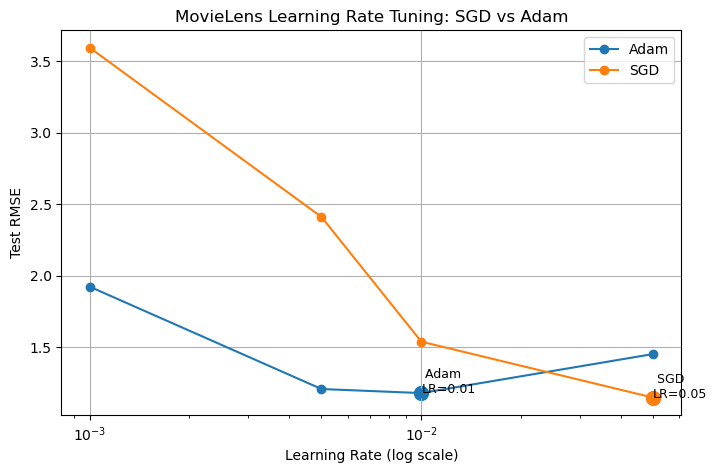

In [45]:
# Learning rate tuning: SGD vs Adam

lr_results_df = pd.concat([
    pd.DataFrame(sgd_lr_results,
                 columns=["Learning Rate", "Test RMSE"]
    ).assign(Optimizer="SGD"),

    pd.DataFrame(adam_lr_results,
                 columns=["Learning Rate", "Test RMSE"]
    ).assign(Optimizer="Adam")
], ignore_index=True)

plt.figure(figsize=(8, 5))

for opt, df in lr_results_df.groupby("Optimizer"):

    df = df.sort_values("Learning Rate")

    plt.plot(
        df["Learning Rate"],
        df["Test RMSE"],
        marker="o",
        label=opt
    )

    best = df.loc[df["Test RMSE"].idxmin()]

    plt.scatter(best["Learning Rate"],
                best["Test RMSE"], s=100)

    plt.text(
        best["Learning Rate"],
        best["Test RMSE"],
        f" {opt}\nLR={best['Learning Rate']}",
        fontsize=9
    )

plt.xscale("log")

plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Test RMSE")
plt.title("MovieLens Learning Rate Tuning: SGD vs Adam")

plt.legend()
plt.grid(True)

plt.savefig(
    movielens_fig_dir / "lr_tuning_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Learning Rate Tuning Interpretation

The learning rate tuning results show clear differences in how SGD and Adam respond to changes in step size during optimization. For SGD, predictive performance improves substantially as the learning rate increases, with RMSE decreasing sharply from approximately 3.59 at 0.001 to 1.15 at 0.05. This behavior indicates that SGD requires a relatively larger learning rate to effectively optimize the sparse matrix factorization model and learn meaningful latent user–item representations.

Adam demonstrates greater stability across learning rates, maintaining comparatively lower RMSE values even at smaller step sizes. The best Adam performance is achieved at a learning rate of 0.01, where the optimizer attains its lowest test RMSE. Unlike SGD, Adam degrades more gradually as the learning rate decreases, reflecting the stabilizing effect of its adaptive parameter update mechanism.

Both optimizers achieve their strongest predictive performance at moderate-to-large learning rates, although SGD exhibits substantially higher sensitivity to learning rate selection. These results emphasize the importance of optimizer-specific hyperparameter tuning in sparse recommendation settings, where convergence behavior varies considerably across optimization methods.

#### Selecting the best k value

In [46]:
# Matrix Factorization Setup for MovieLens
# Shared setup for SGD and Adam optimizers
#-------------------------------------------------------------

# Convert sparse matrices to COO format
# COO format allows efficient access to observed user-item ratings
R_train_coo = R_train.tocoo()
R_test_coo = R_test.tocoo()

# Matrix dimensions
n_users, n_movies = R_train.shape

# Selected model settings
k = 40           # number of latent factors
n_epochs = 12    # number of training epochs
reg = 0.1        # L2 regularization strength

# Global mean rating from training data
global_mean = R_train_coo.data.mean()


def compute_biased_mf_rmse(
    R_coo,
    P,
    Q,
    global_mean,
    user_bias,
    movie_bias
):
    """
    Compute RMSE for biased matrix factorization
    using observed entries only.
    """

    preds = (
        global_mean
        + user_bias[R_coo.row]
        + movie_bias[R_coo.col]
        + np.sum(
            P[R_coo.row] * Q[R_coo.col],
            axis=1
        )
    )

    # Keep predictions within valid MovieLens range
    preds = np.clip(preds, 1, 5)

    errors = R_coo.data - preds

    return np.sqrt(np.mean(errors ** 2))

#### SDG Model

In [47]:
# Biased Matrix Factorization with SGD

lr_sgd = 0.05
rng = np.random.default_rng(SEED)

P_sgd = 0.1 * rng.standard_normal((n_users, k))
Q_sgd = 0.1 * rng.standard_normal((n_movies, k))
user_bias_sgd = np.zeros(n_users)
movie_bias_sgd = np.zeros(n_movies)

sgd_train_rmse, sgd_test_rmse = [], []

start_time = time.time()

for epoch in range(n_epochs):

    for idx in rng.permutation(len(R_train_coo.data)):

        u, i, r_ui = (
            R_train_coo.row[idx],
            R_train_coo.col[idx],
            R_train_coo.data[idx]
        )

        pred = global_mean + user_bias_sgd[u] + movie_bias_sgd[i] + P_sgd[u] @ Q_sgd[i]
        err = r_ui - pred
        P_old = P_sgd[u].copy()

        user_bias_sgd[u] += lr_sgd * (err - reg * user_bias_sgd[u])
        movie_bias_sgd[i] += lr_sgd * (err - reg * movie_bias_sgd[i])
        P_sgd[u] += lr_sgd * (err * Q_sgd[i] - reg * P_sgd[u])
        Q_sgd[i] += lr_sgd * (err * P_old - reg * Q_sgd[i])

    train_rmse = compute_biased_mf_rmse(
        R_train_coo, P_sgd, Q_sgd, global_mean,
        user_bias_sgd, movie_bias_sgd
    )

    test_rmse = compute_biased_mf_rmse(
        R_test_coo, P_sgd, Q_sgd, global_mean,
        user_bias_sgd, movie_bias_sgd
    )

    sgd_train_rmse.append(train_rmse)
    sgd_test_rmse.append(test_rmse)

    print(
        f"Epoch {epoch + 1}/{n_epochs} | "
        f"Train RMSE: {train_rmse:.4f} | "
        f"Test RMSE: {test_rmse:.4f}"
    )

sgd_time = time.time() - start_time

sgd_results = {
    "model": "Biased Matrix Factorization + SGD",
    "k": k,
    "lr": lr_sgd,
    "reg": reg,
    "epochs": n_epochs,
    "train_rmse": sgd_train_rmse,
    "test_rmse": sgd_test_rmse,
    "final_train_rmse": sgd_train_rmse[-1],
    "final_test_rmse": sgd_test_rmse[-1],
    "best_test_rmse": min(sgd_test_rmse),
    "best_epoch": np.argmin(sgd_test_rmse) + 1,
    "runtime_seconds": sgd_time
}

print(
    "\nFinal Biased SGD Results"
    f"\nLatent factors k: {k}"
    f"\nLearning rate: {lr_sgd}"
    f"\nRegularization: {reg}"
    f"\nEpochs: {n_epochs}"
    f"\nRuntime: {sgd_time:.2f} seconds"
    f"\nFinal Train RMSE: {sgd_results['final_train_rmse']:.4f}"
    f"\nFinal Test RMSE: {sgd_results['final_test_rmse']:.4f}"
    f"\nBest Test RMSE: {sgd_results['best_test_rmse']:.4f}"
    f"\nBest Epoch: {sgd_results['best_epoch']}"
)

Epoch 1/12 | Train RMSE: 0.8133 | Test RMSE: 0.8634
Epoch 2/12 | Train RMSE: 0.7901 | Test RMSE: 0.8572
Epoch 3/12 | Train RMSE: 0.7736 | Test RMSE: 0.8554
Epoch 4/12 | Train RMSE: 0.7545 | Test RMSE: 0.8542
Epoch 5/12 | Train RMSE: 0.7335 | Test RMSE: 0.8538
Epoch 6/12 | Train RMSE: 0.7099 | Test RMSE: 0.8528
Epoch 7/12 | Train RMSE: 0.6852 | Test RMSE: 0.8517
Epoch 8/12 | Train RMSE: 0.6597 | Test RMSE: 0.8511
Epoch 9/12 | Train RMSE: 0.6363 | Test RMSE: 0.8511
Epoch 10/12 | Train RMSE: 0.6147 | Test RMSE: 0.8503
Epoch 11/12 | Train RMSE: 0.5959 | Test RMSE: 0.8504
Epoch 12/12 | Train RMSE: 0.5793 | Test RMSE: 0.8501

Final Biased SGD Results
Latent factors k: 40
Learning rate: 0.05
Regularization: 0.1
Epochs: 12
Runtime: 120.93 seconds
Final Train RMSE: 0.5793
Final Test RMSE: 0.8501
Best Test RMSE: 0.8501
Best Epoch: 12


#### Single-Level SGD Performance

The stochastic gradient descent (SGD) matrix factorization model shows steady improvement across all 12 epochs. Training RMSE decreases from 0.8133 to 0.5793, indicating that the model progressively learns stronger user–item latent representations. Test RMSE also decreases from 0.8634 to 0.8501, with the best test RMSE achieved at Epoch 12.

The final test RMSE of 0.8501 is a clear improvement over the Global Mean Predictor baseline test RMSE of 1.0355. The gap between the final training RMSE and test RMSE suggests some overfitting, since the model fits the observed training ratings more closely than the unseen test ratings. The model was trained with k=40, learning rate 0.05, and regularization 0.1, requiring approximately 103.82 seconds.

### Plot SDG 

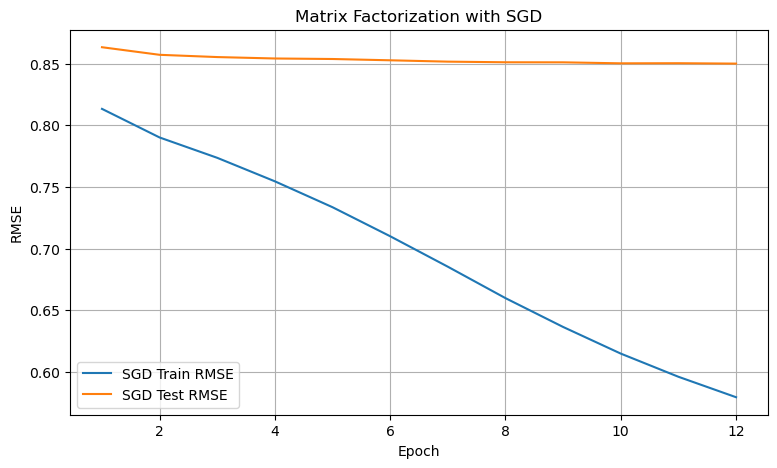

In [48]:
plt.figure(figsize=(9, 5))
plt.plot(range(1, n_epochs + 1), sgd_train_rmse, label="SGD Train RMSE")
plt.plot(range(1, n_epochs + 1), sgd_test_rmse, label="SGD Test RMSE")

plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Matrix Factorization with SGD")
plt.legend()
plt.grid(True)
plt.show()

#### SGD Convergence Behavior (Matrix Factorization)

The SGD matrix factorization model demonstrates stable convergence throughout the training process. Training RMSE decreases steadily from approximately 0.81 to 0.58 across the 12 epochs, indicating continuous improvement in learning latent user–item relationships. Test RMSE also declines during the early epochs, dropping from approximately 0.86 to 0.85, showing that the model rapidly captures the most important generalizable interaction patterns in the sparse recommendation data.

After the initial epochs, the test RMSE begins to stabilize while the training RMSE continues decreasing. This widening gap between training and test RMSE suggests that later optimization stages increasingly improve the fit to the observed training data with only marginal improvement in predictive performance on unseen ratings. The smooth behavior of both curves indicates stable optimization without evidence of divergence or unstable parameter updates during training.

#### Adam Model

In [49]:
# Biased Matrix Factorization with Adam

lr_adam, beta1, beta2, eps = 0.01, 0.9, 0.999, 1e-8

rng = np.random.default_rng(SEED)

P_adam = 0.1 * rng.standard_normal((n_users, k))
Q_adam = 0.1 * rng.standard_normal((n_movies, k))

user_bias_adam = np.zeros(n_users)
movie_bias_adam = np.zeros(n_movies)

mP, vP = np.zeros_like(P_adam), np.zeros_like(P_adam)
mQ, vQ = np.zeros_like(Q_adam), np.zeros_like(Q_adam)

m_user_bias = np.zeros_like(user_bias_adam)
v_user_bias = np.zeros_like(user_bias_adam)

m_movie_bias = np.zeros_like(movie_bias_adam)
v_movie_bias = np.zeros_like(movie_bias_adam)

adam_train_rmse, adam_test_rmse = [], []

t = 0
start_time = time.time()

for epoch in range(n_epochs):

    for idx in rng.permutation(len(R_train_coo.data)):

        t += 1

        u, i, r_ui = (
            R_train_coo.row[idx],
            R_train_coo.col[idx],
            R_train_coo.data[idx]
        )

        pred = (
            global_mean
            + user_bias_adam[u]
            + movie_bias_adam[i]
            + P_adam[u] @ Q_adam[i]
        )

        err = r_ui - pred

        P_old, Q_old = P_adam[u].copy(), Q_adam[i].copy()

        grad_P = -err * Q_old + reg * P_old
        grad_Q = -err * P_old + reg * Q_old

        grad_ub = -err + reg * user_bias_adam[u]
        grad_mb = -err + reg * movie_bias_adam[i]

        for param, grad, m, v in [
            (P_adam[u], grad_P, mP[u], vP[u]),
            (Q_adam[i], grad_Q, mQ[i], vQ[i]),
            (user_bias_adam[u:u+1], np.array([grad_ub]),
             m_user_bias[u:u+1], v_user_bias[u:u+1]),
            (movie_bias_adam[i:i+1], np.array([grad_mb]),
             m_movie_bias[i:i+1], v_movie_bias[i:i+1])
        ]:

            m[:] = beta1 * m + (1 - beta1) * grad
            v[:] = beta2 * v + (1 - beta2) * (grad ** 2)

            m_hat = m / (1 - beta1 ** t)
            v_hat = v / (1 - beta2 ** t)

            param -= lr_adam * m_hat / (np.sqrt(v_hat) + eps)

    train_rmse = compute_biased_mf_rmse(
        R_train_coo, P_adam, Q_adam,
        global_mean, user_bias_adam, movie_bias_adam
    )

    test_rmse = compute_biased_mf_rmse(
        R_test_coo, P_adam, Q_adam,
        global_mean, user_bias_adam, movie_bias_adam
    )

    adam_train_rmse.append(train_rmse)
    adam_test_rmse.append(test_rmse)

    print(
        f"Adam Epoch {epoch + 1}/{n_epochs} | "
        f"Train RMSE: {train_rmse:.4f} | "
        f"Test RMSE: {test_rmse:.4f}"
    )

adam_time = time.time() - start_time

adam_results = {
    "model": "Biased Matrix Factorization + Adam",
    "k": k,
    "lr": lr_adam,
    "reg": reg,
    "epochs": n_epochs,
    "train_rmse": adam_train_rmse,
    "test_rmse": adam_test_rmse,
    "final_train_rmse": adam_train_rmse[-1],
    "final_test_rmse": adam_test_rmse[-1],
    "best_test_rmse": min(adam_test_rmse),
    "best_epoch": np.argmin(adam_test_rmse) + 1,
    "runtime_seconds": adam_time
}

print(
    "\nFinal Biased Adam Results"
    f"\nLatent factors k: {k}"
    f"\nLearning rate: {lr_adam}"
    f"\nRegularization: {reg}"
    f"\nEpochs: {n_epochs}"
    f"\nRuntime: {adam_time:.2f} seconds"
    f"\nFinal Train RMSE: {adam_results['final_train_rmse']:.4f}"
    f"\nFinal Test RMSE: {adam_results['final_test_rmse']:.4f}"
    f"\nBest Test RMSE: {adam_results['best_test_rmse']:.4f}"
    f"\nBest Epoch: {adam_results['best_epoch']}"
)

Adam Epoch 1/12 | Train RMSE: 0.7565 | Test RMSE: 0.8682
Adam Epoch 2/12 | Train RMSE: 0.6498 | Test RMSE: 0.8563
Adam Epoch 3/12 | Train RMSE: 0.5762 | Test RMSE: 0.8541
Adam Epoch 4/12 | Train RMSE: 0.5360 | Test RMSE: 0.8530
Adam Epoch 5/12 | Train RMSE: 0.5155 | Test RMSE: 0.8519
Adam Epoch 6/12 | Train RMSE: 0.5044 | Test RMSE: 0.8519
Adam Epoch 7/12 | Train RMSE: 0.4975 | Test RMSE: 0.8512
Adam Epoch 8/12 | Train RMSE: 0.4921 | Test RMSE: 0.8509
Adam Epoch 9/12 | Train RMSE: 0.4887 | Test RMSE: 0.8514
Adam Epoch 10/12 | Train RMSE: 0.4853 | Test RMSE: 0.8510
Adam Epoch 11/12 | Train RMSE: 0.4822 | Test RMSE: 0.8512
Adam Epoch 12/12 | Train RMSE: 0.4792 | Test RMSE: 0.8508

Final Biased Adam Results
Latent factors k: 40
Learning rate: 0.01
Regularization: 0.1
Epochs: 12
Runtime: 409.18 seconds
Final Train RMSE: 0.4792
Final Test RMSE: 0.8508
Best Test RMSE: 0.8508
Best Epoch: 12


#### Single-Level Adam Performance

The Adam matrix factorization model shows rapid reduction in training RMSE, decreasing from 0.7565 in Epoch 1 to 0.4792 by Epoch 12. Test RMSE also improves from 0.8682 to 0.8508, with the best test RMSE achieved at the final epoch.

Adam fits the training data more strongly than SGD, as shown by its lower final training RMSE. However, its final test RMSE of 0.8508 is very close to the SGD result of 0.8501, indicating that the stronger training optimization does not produce a meaningful improvement in test performance. The model used k=40, learning rate 0.01, and regularization 0.1, with a total runtime of approximately 454.68 seconds.

#### Plot Adam 

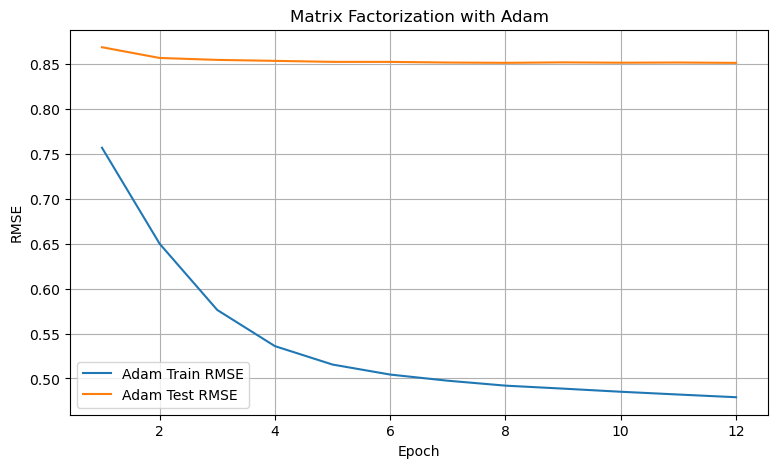

In [50]:
# Plot Adam RMSE
plt.figure(figsize=(9, 5))

plt.plot(range(1, n_epochs + 1), adam_train_rmse, label="Adam Train RMSE")
plt.plot(range(1, n_epochs + 1), adam_test_rmse, label="Adam Test RMSE")

plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Matrix Factorization with Adam")

plt.legend()
plt.grid(True)
plt.show()

#### Adam Convergence Behavior (Matrix Factorization)

The Adam matrix factorization model demonstrates rapid convergence during the early epochs of training. Training RMSE decreases sharply from approximately 0.76 to 0.54 within the first four epochs, while test RMSE also declines quickly before stabilizing near 0.85. This behavior indicates that Adam efficiently captures the dominant latent user–item interaction structure during the initial stages of optimization.

After the early epochs, the training RMSE continues decreasing steadily, eventually reaching approximately 0.48, whereas the test RMSE shows only marginal improvement. The widening gap between training and test RMSE suggests that later optimization stages increasingly improve the fit to the training data without substantially improving predictive performance on unseen ratings.

Compared to SGD, Adam achieves lower training RMSE throughout training, reflecting stronger optimization of the training objective. However, the final test RMSE remains nearly identical to the SGD result, indicating that the additional reduction in training error does not translate into meaningful improvement in recommendation accuracy on unseen data.

#### Combined comparison plot (SGD vs Adam, train + test RMSE)

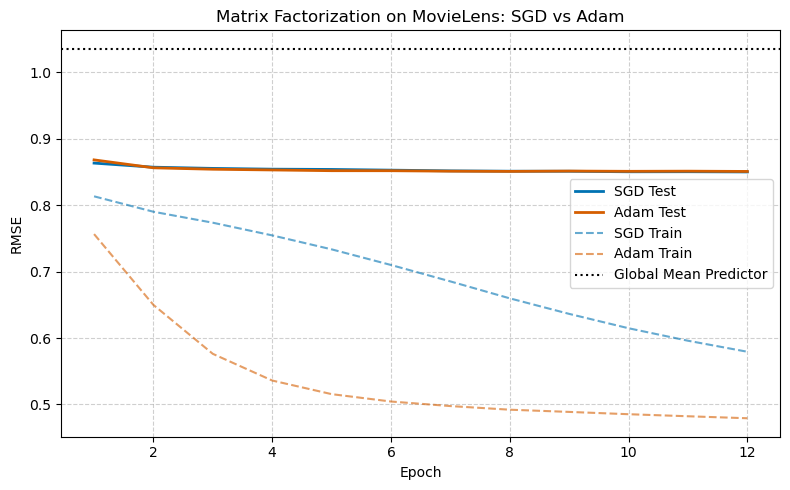

In [51]:
epochs = range(1, n_epochs + 1)

# Colorblind-safe palette
colors = {
    "sgd": "#0072B2",   # blue
    "adam": "#D55E00"   # orange
}

plt.figure(figsize=(8, 5))

# Test curves (main focus)
plt.plot(epochs, sgd_test_rmse, color=colors["sgd"], linewidth=2, label="SGD Test")
plt.plot(epochs, adam_test_rmse, color=colors["adam"], linewidth=2, label="Adam Test")

# Train curves (lighter style)
plt.plot(epochs, sgd_train_rmse, linestyle="--", alpha=0.6, color=colors["sgd"], label="SGD Train")
plt.plot(epochs, adam_train_rmse, linestyle="--", alpha=0.6, color=colors["adam"], label="Adam Train")

# Baseline (global mean)
plt.axhline(
    y=test_rmse_baseline,
    color="black",
    linestyle=":",
    linewidth=1.5,
    label="Global Mean Predictor"
)

# Labels
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Matrix Factorization on MovieLens: SGD vs Adam")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.savefig(
    movielens_fig_dir / "mf_rmse_plot_sgd_vs_adam.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Optimizer Comparison: SGD vs Adam (MovieLens)

Both SGD and Adam demonstrate rapid reductions in RMSE during the early training epochs, indicating that the dominant latent user–item interaction patterns are learned quickly. Adam converges faster during the initial stages of optimization, achieving lower training RMSE values earlier than SGD. In contrast, SGD improves more gradually but maintains stable convergence behavior throughout training.

The test RMSE curves for both optimizers decrease early and then stabilize near 0.85, with only marginal improvements during later epochs. Although Adam achieves substantially lower training RMSE than SGD, the final test RMSE values remain nearly identical, indicating that the stronger optimization of the training objective does not produce meaningful gains in predictive accuracy on unseen ratings.

The baseline global mean predictor produces a substantially higher RMSE than both matrix factorization methods, demonstrating the effectiveness of personalized latent factor modeling for sparse recommendation data. The similarity in final test RMSE between SGD and Adam suggests that optimizer selection has limited impact on generalization performance once the models are properly tuned. Adam provides faster convergence and stronger fitting of the training data, whereas SGD achieves comparable test performance with lower computational cost.

#### Comparison Table 

In [52]:
# Matrix Factorization Optimizer Comparison
# Optimizer Comparison Table 

optimizer_results = pd.DataFrame({
    "Optimizer": ["SGD", "Adam"],
    "Final Train RMSE": [sgd_train_rmse[-1], adam_train_rmse[-1]],
    "Final Test RMSE": [sgd_test_rmse[-1], adam_test_rmse[-1]],
    "Training Time (s)": [sgd_time, adam_time]
})

# Round values for clean display
optimizer_results = optimizer_results.round({
    "Final Train RMSE": 4,
    "Final Test RMSE": 4,
    "Training Time (s)": 2
})

# Sort by best performance (lowest test RMSE)
optimizer_results = optimizer_results.sort_values("Final Test RMSE")

optimizer_results.reset_index(drop=True, inplace=True)

optimizer_results

,Optimizer,Final Train RMSE,Final Test RMSE,Training Time (s)
0,SGD,0.5793,0.8501,120.93
1,Adam,0.4792,0.8508,409.18


### Multilevel Training (Embedding Expansion)

In [53]:
# Multilevel Matrix Factorization Setup for MovieLens
# Shared setup for Multilevel SGD and Multilevel Adam
# -------------------------------------------------------------

# Convert sparse matrices to COO format
R_train_coo, R_test_coo = R_train.tocoo(), R_test.tocoo()

# Matrix dimensions
n_users, n_movies = R_train.shape

# Multilevel settings
k_levels = [5, 10, 20, 40]   # final k matches single-level k = 40
epochs_per_level = 3         # total epochs = 12
total_epochs = len(k_levels) * epochs_per_level
reg = 0.1

# Global mean rating
global_mean = R_train_coo.data.mean()


def compute_biased_mf_rmse(R_coo, P, Q, global_mean, user_bias, movie_bias):
    """
    Compute RMSE for biased matrix factorization using observed ratings only.
    """

    preds = (
        global_mean
        + user_bias[R_coo.row]
        + movie_bias[R_coo.col]
        + np.sum(P[R_coo.row] * Q[R_coo.col], axis=1)
    )

    preds = np.clip(preds, 1, 5)

    return np.sqrt(np.mean((R_coo.data - preds) ** 2))

#### Multilevel SGD

In [54]:
# Biased Multilevel Matrix Factorization with SGD

lr_ml_sgd = 0.05
rng = np.random.default_rng(SEED)

P_ml_sgd = 0.1 * rng.standard_normal((n_users, k_levels[0]))
Q_ml_sgd = 0.1 * rng.standard_normal((n_movies, k_levels[0]))

user_bias_ml_sgd = np.zeros(n_users)
movie_bias_ml_sgd = np.zeros(n_movies)

ml_sgd_train_rmse, ml_sgd_test_rmse, ml_sgd_level_history = [], [], []

start_time = time.time()

for level_idx, current_k in enumerate(k_levels):

    print(f"\nTraining Biased Multilevel SGD at k = {current_k}")

    for epoch in range(epochs_per_level):

        for idx in rng.permutation(len(R_train_coo.data)):

            u, i, r_ui = (
                R_train_coo.row[idx],
                R_train_coo.col[idx],
                R_train_coo.data[idx]
            )

            pred = global_mean + user_bias_ml_sgd[u] + movie_bias_ml_sgd[i] + P_ml_sgd[u] @ Q_ml_sgd[i]
            err = r_ui - pred
            P_old = P_ml_sgd[u].copy()

            user_bias_ml_sgd[u] += lr_ml_sgd * (err - reg * user_bias_ml_sgd[u])
            movie_bias_ml_sgd[i] += lr_ml_sgd * (err - reg * movie_bias_ml_sgd[i])
            P_ml_sgd[u] += lr_ml_sgd * (err * Q_ml_sgd[i] - reg * P_ml_sgd[u])
            Q_ml_sgd[i] += lr_ml_sgd * (err * P_old - reg * Q_ml_sgd[i])

        train_rmse = compute_biased_mf_rmse(
            R_train_coo, P_ml_sgd, Q_ml_sgd,
            global_mean, user_bias_ml_sgd, movie_bias_ml_sgd
        )

        test_rmse = compute_biased_mf_rmse(
            R_test_coo, P_ml_sgd, Q_ml_sgd,
            global_mean, user_bias_ml_sgd, movie_bias_ml_sgd
        )

        ml_sgd_train_rmse.append(train_rmse)
        ml_sgd_test_rmse.append(test_rmse)
        ml_sgd_level_history.append(current_k)

        print(
            f"k={current_k} | Epoch {epoch + 1}/{epochs_per_level} | "
            f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}"
        )

    if level_idx < len(k_levels) - 1:
        next_k = k_levels[level_idx + 1]
        extra = next_k - current_k

        print(f"\nStarting level {level_idx + 2}: k={next_k}")
        print(f"Transferred MF latent factors: k={current_k} → k={next_k}")

        P_ml_sgd = np.hstack([P_ml_sgd, np.zeros((n_users, extra))])
        Q_ml_sgd = np.hstack([Q_ml_sgd, np.zeros((n_movies, extra))])

ml_sgd_time = time.time() - start_time

ml_sgd_results = {
    "model": "Biased Multilevel Matrix Factorization + SGD",
    "k_levels": k_levels,
    "final_k": k_levels[-1],
    "lr": lr_ml_sgd,
    "reg": reg,
    "epochs_per_level": epochs_per_level,
    "total_epochs": total_epochs,
    "train_rmse": ml_sgd_train_rmse,
    "test_rmse": ml_sgd_test_rmse,
    "level_history": ml_sgd_level_history,
    "final_train_rmse": ml_sgd_train_rmse[-1],
    "final_test_rmse": ml_sgd_test_rmse[-1],
    "best_test_rmse": min(ml_sgd_test_rmse),
    "best_epoch": np.argmin(ml_sgd_test_rmse) + 1,
    "runtime_seconds": ml_sgd_time
}

print(
    "\nFinal Biased Multilevel SGD Results"
    f"\nk levels: {k_levels}"
    f"\nFinal k: {k_levels[-1]}"
    f"\nLearning rate: {lr_ml_sgd}"
    f"\nRegularization: {reg}"
    f"\nTotal epochs: {total_epochs}"
    f"\nRuntime: {ml_sgd_time:.2f} seconds"
    f"\nFinal Train RMSE: {ml_sgd_results['final_train_rmse']:.4f}"
    f"\nFinal Test RMSE: {ml_sgd_results['final_test_rmse']:.4f}"
    f"\nBest Test RMSE: {ml_sgd_results['best_test_rmse']:.4f}"
    f"\nBest Epoch: {ml_sgd_results['best_epoch']}"
)


Training Biased Multilevel SGD at k = 5
k=5 | Epoch 1/3 | Train RMSE: 0.8255 | Test RMSE: 0.8625
k=5 | Epoch 2/3 | Train RMSE: 0.8080 | Test RMSE: 0.8560
k=5 | Epoch 3/3 | Train RMSE: 0.7978 | Test RMSE: 0.8532

Starting level 2: k=10
Transferred MF latent factors: k=5 → k=10

Training Biased Multilevel SGD at k = 10
k=10 | Epoch 1/3 | Train RMSE: 0.7912 | Test RMSE: 0.8555
k=10 | Epoch 2/3 | Train RMSE: 0.7830 | Test RMSE: 0.8550
k=10 | Epoch 3/3 | Train RMSE: 0.7740 | Test RMSE: 0.8546

Starting level 3: k=20
Transferred MF latent factors: k=10 → k=20

Training Biased Multilevel SGD at k = 20
k=20 | Epoch 1/3 | Train RMSE: 0.7661 | Test RMSE: 0.8568
k=20 | Epoch 2/3 | Train RMSE: 0.7551 | Test RMSE: 0.8549
k=20 | Epoch 3/3 | Train RMSE: 0.7452 | Test RMSE: 0.8567

Starting level 4: k=40
Transferred MF latent factors: k=20 → k=40

Training Biased Multilevel SGD at k = 40
k=40 | Epoch 1/3 | Train RMSE: 0.7348 | Test RMSE: 0.8574
k=40 | Epoch 2/3 | Train RMSE: 0.7251 | Test RMSE: 0.857

#### Multilevel SGD Performance

The multilevel SGD model demonstrates progressive learning as the latent dimensionality increases from k=5 to k=40. Training RMSE decreases steadily from 0.8255 at the first level to 0.7161 at the final level, indicating continuous refinement of latent user–item representations through transferred factor initialization. Test RMSE improves during the early levels, reaching its best value of 0.8532 at Epoch 3 under k=5, before fluctuating slightly during later levels.

Compared to single-level SGD, the multilevel approach produces a higher final training RMSE and a slightly higher final test RMSE of 0.8593. The results suggest that increasing latent dimensionality beyond the earlier levels provides only marginal improvement in predictive performance on unseen ratings. The test RMSE remains relatively stable across level transitions, indicating that most meaningful generalization performance is achieved during the initial training stages.

A key advantage of multilevel SGD is its computational efficiency. The model completes training in approximately 49.53 seconds, which is substantially faster than the single-level SGD and Adam-based approaches while maintaining comparable recommendation accuracy.

#### Multilevel SGD plot

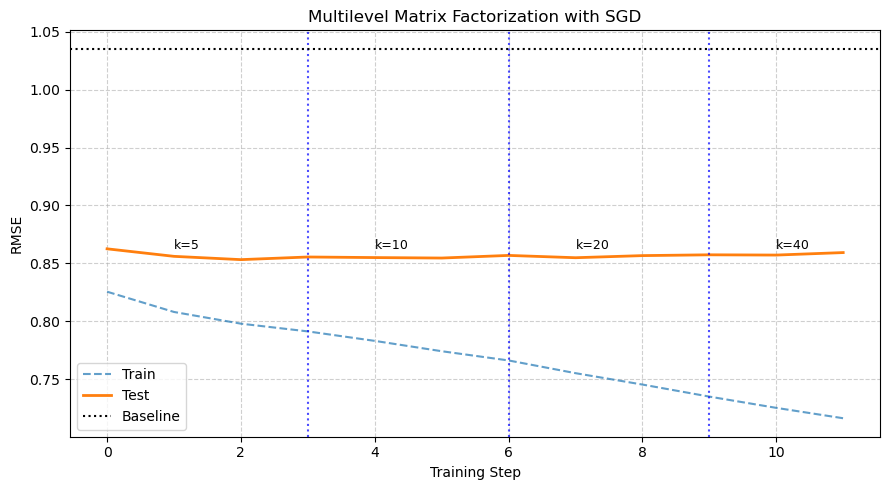

In [55]:
plt.figure(figsize=(9, 5))

# RMSE curves
plt.plot(ml_sgd_train_rmse, "--", alpha=0.7, label="Train")
plt.plot(ml_sgd_test_rmse, linewidth=2, label="Test")

# Level boundaries and labels
for i, k_val in enumerate(k_levels[:-1]):
    boundary = (i + 1) * epochs_per_level
    plt.axvline(boundary, color="blue", linestyle=":", alpha=0.7)

for i, k_val in enumerate(k_levels):
    plt.text(
        i * epochs_per_level + 1,
        max(ml_sgd_test_rmse),
        f"k={k_val}",
        fontsize=9
    )

# Baseline
plt.axhline(
    test_rmse_baseline,
    color="black",
    linestyle=":",
    linewidth=1.5,
    label="Baseline"
)

plt.xlabel("Training Step")
plt.ylabel("RMSE")
plt.title("Multilevel Matrix Factorization with SGD")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()

plt.savefig(
    movielens_fig_dir / "multilevel_mf_rmse_plot_sgd.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Discussion and Interpretation

The multilevel matrix factorization model with SGD demonstrates gradual learning as the latent dimension increases from k=5 to k=40. The training RMSE decreases steadily across all levels, indicating continuous refinement of latent user–item representations as additional latent factors are introduced. Test RMSE improves during the early stages of training, reaching its best performance near the first level transition, before stabilizing around 0.85 in the later levels.

The largest improvement in predictive performance occurs at the lower embedding dimensions, particularly between k=5 and k=10. Beyond this point, increases in latent dimensionality produce only marginal changes in test RMSE, suggesting diminishing returns from larger embeddings. While higher-dimensional latent spaces improve the model’s ability to fit the training data, these additional parameters do not substantially improve recommendation accuracy on unseen ratings.

The comparison with the global mean baseline shows that the multilevel matrix factorization model achieves substantially lower RMSE throughout training, demonstrating the effectiveness of personalized latent factor learning for sparse recommendation data. The stable test RMSE curve across level transitions also indicates that the transferred latent factors preserve previously learned interaction structure while allowing incremental refinement at higher dimensions.

#### Multilevel Adam

In [56]:
# Biased Multilevel Matrix Factorization with Adam

lr_ml_adam, beta1, beta2, eps = 0.01, 0.9, 0.999, 1e-8
rng = np.random.default_rng(SEED)

P_ml_adam = 0.1 * rng.standard_normal((n_users, k_levels[0]))
Q_ml_adam = 0.1 * rng.standard_normal((n_movies, k_levels[0]))

user_bias_ml_adam = np.zeros(n_users)
movie_bias_ml_adam = np.zeros(n_movies)

mP, vP = np.zeros_like(P_ml_adam), np.zeros_like(P_ml_adam)
mQ, vQ = np.zeros_like(Q_ml_adam), np.zeros_like(Q_ml_adam)
m_user_bias, v_user_bias = np.zeros(n_users), np.zeros(n_users)
m_movie_bias, v_movie_bias = np.zeros(n_movies), np.zeros(n_movies)

ml_adam_train_rmse, ml_adam_test_rmse, ml_adam_level_history = [], [], []

def adam_update(param, grad, m, v, t):
    m[:] = beta1 * m + (1 - beta1) * grad
    v[:] = beta2 * v + (1 - beta2) * grad**2
    param -= lr_ml_adam * (m / (1 - beta1**t)) / (
        np.sqrt(v / (1 - beta2**t)) + eps
    )

t = 0
start_time = time.time()

for level_idx, current_k in enumerate(k_levels):

    print(f"\nTraining Biased Multilevel Adam at k = {current_k}")

    for epoch in range(epochs_per_level):

        for idx in rng.permutation(len(R_train_coo.data)):

            t += 1
            u, i, r_ui = R_train_coo.row[idx], R_train_coo.col[idx], R_train_coo.data[idx]

            pred = global_mean + user_bias_ml_adam[u] + movie_bias_ml_adam[i] + P_ml_adam[u] @ Q_ml_adam[i]
            err = r_ui - pred

            P_old, Q_old = P_ml_adam[u].copy(), Q_ml_adam[i].copy()

            adam_update(P_ml_adam[u], -err * Q_old + reg * P_old, mP[u], vP[u], t)
            adam_update(Q_ml_adam[i], -err * P_old + reg * Q_old, mQ[i], vQ[i], t)
            adam_update(user_bias_ml_adam[u:u+1], np.array([-err + reg * user_bias_ml_adam[u]]),
                        m_user_bias[u:u+1], v_user_bias[u:u+1], t)
            adam_update(movie_bias_ml_adam[i:i+1], np.array([-err + reg * movie_bias_ml_adam[i]]),
                        m_movie_bias[i:i+1], v_movie_bias[i:i+1], t)

        train_rmse = compute_biased_mf_rmse(
            R_train_coo, P_ml_adam, Q_ml_adam,
            global_mean, user_bias_ml_adam, movie_bias_ml_adam
        )

        test_rmse = compute_biased_mf_rmse(
            R_test_coo, P_ml_adam, Q_ml_adam,
            global_mean, user_bias_ml_adam, movie_bias_ml_adam
        )

        ml_adam_train_rmse.append(train_rmse)
        ml_adam_test_rmse.append(test_rmse)
        ml_adam_level_history.append(current_k)

        print(
            f"k={current_k} | Epoch {epoch + 1}/{epochs_per_level} | "
            f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}"
        )

    if level_idx < len(k_levels) - 1:

        next_k = k_levels[level_idx + 1]
        extra = next_k - current_k

        print(f"\nStarting level {level_idx + 2}: k={next_k}")
        print(f"Transferred MF latent factors: k={current_k} → k={next_k}")

        for name in ["P_ml_adam", "mP", "vP"]:
            globals()[name] = np.hstack([globals()[name], np.zeros((n_users, extra))])

        for name in ["Q_ml_adam", "mQ", "vQ"]:
            globals()[name] = np.hstack([globals()[name], np.zeros((n_movies, extra))])

ml_adam_time = time.time() - start_time

ml_adam_results = {
    "model": "Biased Multilevel Matrix Factorization + Adam",
    "k_levels": k_levels,
    "final_k": k_levels[-1],
    "lr": lr_ml_adam,
    "reg": reg,
    "epochs_per_level": epochs_per_level,
    "total_epochs": total_epochs,
    "train_rmse": ml_adam_train_rmse,
    "test_rmse": ml_adam_test_rmse,
    "level_history": ml_adam_level_history,
    "final_train_rmse": ml_adam_train_rmse[-1],
    "final_test_rmse": ml_adam_test_rmse[-1],
    "best_test_rmse": min(ml_adam_test_rmse),
    "best_epoch": np.argmin(ml_adam_test_rmse) + 1,
    "runtime_seconds": ml_adam_time
}

print(
    "\nFinal Biased Multilevel Adam Results"
    f"\nFinal k: {ml_adam_results['final_k']}"
    f"\nTotal epochs: {ml_adam_results['total_epochs']}"
    f"\nRuntime: {ml_adam_time:.2f} seconds"
    f"\nFinal Train RMSE: {ml_adam_results['final_train_rmse']:.4f}"
    f"\nFinal Test RMSE: {ml_adam_results['final_test_rmse']:.4f}"
    f"\nBest Test RMSE: {ml_adam_results['best_test_rmse']:.4f}"
    f"\nBest Epoch: {ml_adam_results['best_epoch']}"
)


Training Biased Multilevel Adam at k = 5
k=5 | Epoch 1/3 | Train RMSE: 0.8126 | Test RMSE: 0.8589
k=5 | Epoch 2/3 | Train RMSE: 0.7771 | Test RMSE: 0.8517
k=5 | Epoch 3/3 | Train RMSE: 0.7409 | Test RMSE: 0.8504

Starting level 2: k=10
Transferred MF latent factors: k=5 → k=10

Training Biased Multilevel Adam at k = 10
k=10 | Epoch 1/3 | Train RMSE: 0.7093 | Test RMSE: 0.8517
k=10 | Epoch 2/3 | Train RMSE: 0.6869 | Test RMSE: 0.8529
k=10 | Epoch 3/3 | Train RMSE: 0.6716 | Test RMSE: 0.8544

Starting level 3: k=20
Transferred MF latent factors: k=10 → k=20

Training Biased Multilevel Adam at k = 20
k=20 | Epoch 1/3 | Train RMSE: 0.6607 | Test RMSE: 0.8561
k=20 | Epoch 2/3 | Train RMSE: 0.6527 | Test RMSE: 0.8563
k=20 | Epoch 3/3 | Train RMSE: 0.6466 | Test RMSE: 0.8572

Starting level 4: k=40
Transferred MF latent factors: k=20 → k=40

Training Biased Multilevel Adam at k = 40
k=40 | Epoch 1/3 | Train RMSE: 0.6423 | Test RMSE: 0.8579
k=40 | Epoch 2/3 | Train RMSE: 0.6392 | Test RMSE: 0

#### Multilevel Adam Performance

The multilevel Adam matrix factorization model demonstrates strong optimization performance as the latent dimensionality increases progressively from k=5 to k=40. Training RMSE decreases steadily from 0.8126 to 0.6366, indicating continuous refinement of latent user–item representations across levels. Test RMSE improves rapidly during the first level, reaching its best value of 0.8504 at Epoch 3 under k=5, before gradually increasing during subsequent level expansions.

The results show that most generalizable learning occurs during the early stages of training at lower embedding dimensions. As the latent dimension increases beyond k=10, the model continues reducing training RMSE while test RMSE remains relatively stable and slightly worsens in later levels. This widening gap between training and test RMSE suggests that the additional model complexity primarily improves the fit to the training data without improving recommendation accuracy on unseen ratings.

Compared to single-level Adam and SGD-based approaches, the multilevel Adam model achieves similar test RMSE performance while requiring additional computational cost. The model completes training in approximately 240.49 seconds, substantially longer than multilevel SGD. These results indicate that progressive latent factor expansion improves training optimization but provides limited gains in predictive generalization for this sparse recommendation setting.

#### Multilevel Adam plot

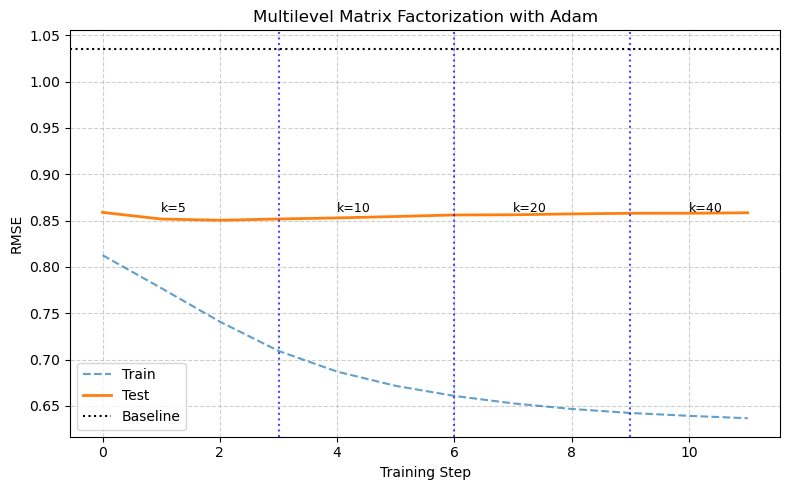

In [57]:
# Plot Multilevel Matrix Factorization with Adam

plt.figure(figsize=(8, 5))

# RMSE curves
plt.plot(ml_adam_train_rmse, "--", alpha=0.7, label="Train")
plt.plot(ml_adam_test_rmse, linewidth=2, label="Test")

# Level boundaries and labels
for i, k_val in enumerate(k_levels[:-1]):
    boundary = (i + 1) * epochs_per_level
    plt.axvline(boundary, color="blue", linestyle=":", alpha=0.7)

for i, k_val in enumerate(k_levels):
    plt.text(
        i * epochs_per_level + 1,
        max(ml_adam_test_rmse),
        f"k={k_val}",
        fontsize=9
    )

# Baseline
plt.axhline(
    test_rmse_baseline,
    color="black",
    linestyle=":",
    linewidth=1.5,
    label="Baseline"
)

plt.xlabel("Training Step")
plt.ylabel("RMSE")
plt.title("Multilevel Matrix Factorization with Adam")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()

plt.savefig(
    movielens_fig_dir / "multilevel_mf_rmse_plot_adam.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Multilevel Adam Convergence Behavior

The multilevel Adam matrix factorization model demonstrates rapid learning during the early training stages, particularly at the lower embedding dimensions. Test RMSE decreases quickly from approximately 0.859 to 0.850 during the k=5 level, indicating that the model efficiently captures the dominant user–item interaction structure within the first few training steps. The training RMSE also declines sharply, reflecting strong optimization of the latent factors.

As the latent dimensionality increases from k=10 to k=40, the training RMSE continues to decrease steadily, reaching approximately 0.637 by the final level. However, the test RMSE remains relatively stable and gradually increases slightly across later levels, indicating diminishing returns from increasing model complexity. This widening gap between training and test RMSE suggests that later training stages primarily improve the fit to the observed training data without yielding meaningful improvements in recommendation accuracy on unseen ratings.

The comparison with the global mean baseline shows that the multilevel Adam model consistently achieves substantially lower RMSE throughout training, confirming the effectiveness of latent factor learning for sparse recommendation problems. The stable convergence pattern across level transitions also indicates that transferred latent factors preserve previously learned interaction structure while enabling progressive parameter refinement at higher dimensions.

### Multilevel Plot Comparison

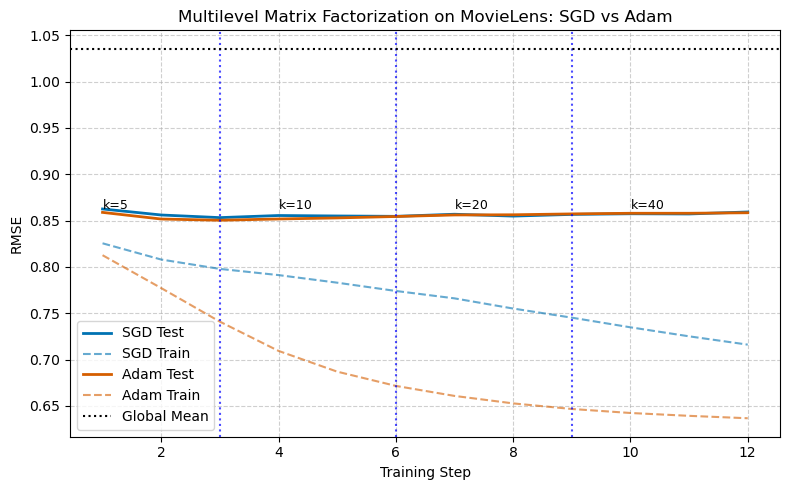

In [58]:
# Multilevel Matrix Factorization: SGD vs Adam

steps = range(1, total_epochs + 1)
colors = {"SGD": "#0072B2", "Adam": "#D55E00"}

plt.figure(figsize=(8, 5))

for name, train, test in [
    ("SGD", ml_sgd_train_rmse, ml_sgd_test_rmse),
    ("Adam", ml_adam_train_rmse, ml_adam_test_rmse)
]:
    plt.plot(steps, test, color=colors[name], linewidth=2, label=f"{name} Test")
    plt.plot(steps, train, color=colors[name], linestyle="--", alpha=0.6, label=f"{name} Train")

for i, k_val in enumerate(k_levels):
    if i > 0:
        plt.axvline(i * epochs_per_level, color="blue", linestyle=":", alpha=0.7)
    plt.text(
        i * epochs_per_level + 1,
        max(max(ml_sgd_test_rmse), max(ml_adam_test_rmse)),
        f"k={k_val}",
        fontsize=9
    )

plt.axhline(
    test_rmse_baseline,
    color="black",
    linestyle=":",
    linewidth=1.5,
    label="Global Mean"
)

plt.xlabel("Training Step")
plt.ylabel("RMSE")
plt.title("Multilevel Matrix Factorization on MovieLens: SGD vs Adam")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.savefig(
    movielens_fig_dir / "multilevel_mf_rmse_plot_sgd_vs_adam.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Multilevel summary

The multilevel matrix factorization comparison shows that both SGD and Adam achieve very similar test RMSE performance throughout training, with both models stabilizing around 0.85 after the early training stages. The largest improvement in test RMSE occurs during the first level (k=5), where both optimizers rapidly reduce prediction error. Beyond this point, increases in latent dimensionality from k=10 to k=40 produce only marginal changes in test performance, indicating diminishing returns from progressively larger embeddings.

The training RMSE curves reveal a stronger optimization effect for Adam compared to SGD. Adam reduces training RMSE much more aggressively, reaching substantially lower values by the final level, while SGD exhibits a slower and more gradual decline. Despite this stronger training fit, Adam does not achieve noticeably better test RMSE than SGD, suggesting that the additional optimization primarily improves the fit to the training data rather than enhancing recommendation accuracy on unseen interactions.

Both multilevel approaches consistently outperform the global mean baseline, confirming the effectiveness of latent factor modeling for sparse recommendation data. The stable behavior across level transitions also indicates that transferring latent factors between levels preserves previously learned interaction structure while allowing incremental refinement as the embedding dimension increases.

#### Comparison plot

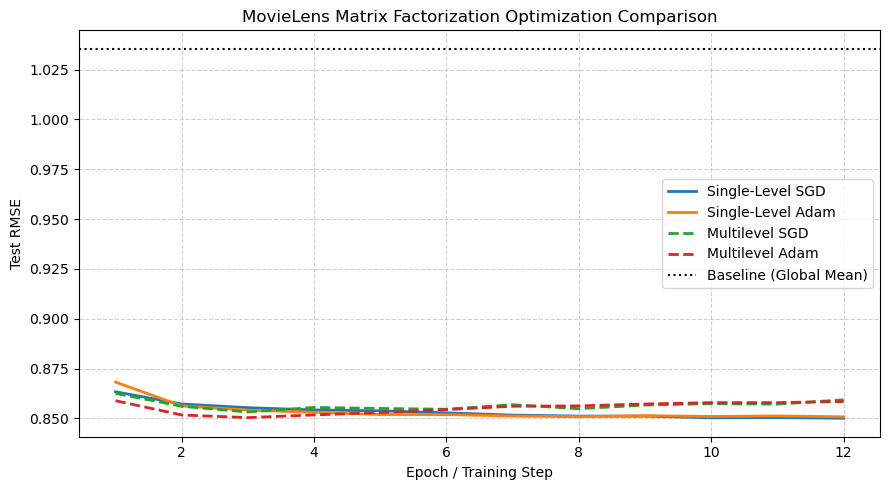

In [59]:
# Full Comparison: Single-Level vs Multilevel MF

plt.figure(figsize=(9, 5))

models = [
    (sgd_test_rmse, "Single-Level SGD", "-"),
    (adam_test_rmse, "Single-Level Adam", "-"),
    (ml_sgd_test_rmse, "Multilevel SGD", "--"),
    (ml_adam_test_rmse, "Multilevel Adam", "--")
]

for rmse, label, style in models:
    plt.plot(
        range(1, len(rmse) + 1),
        rmse,
        linestyle=style,
        linewidth=2,
        label=label
    )

plt.axhline(
    test_rmse_baseline,
    color="black",
    linestyle=":",
    linewidth=1.5,
    label="Baseline (Global Mean)"
)

plt.xlabel("Epoch / Training Step")
plt.ylabel("Test RMSE")
plt.title("MovieLens Matrix Factorization Optimization Comparison")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.savefig(
    movielens_fig_dir / "comparison_mf_rmse_plot_sgd_vs_adam.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### MovieLens Optimization Comparison 

All four matrix factorization models exhibit a rapid reduction in test RMSE during the early training stages, indicating that the dominant user–item interaction patterns are learned quickly. After the first few epochs, the curves stabilize near 0.85 RMSE, showing only marginal improvement in later training stages. This behavior suggests that most generalizable information is captured early, with diminishing returns from additional optimization.

Adam achieves slightly faster initial convergence than SGD, particularly in the first epochs, where it reaches lower RMSE values more quickly. However, as training progresses, both optimizers converge to nearly identical final test RMSE values. The multilevel approaches also closely track the single-level models throughout training, indicating that progressively increasing the latent dimensionality provides limited improvement in predictive performance for this sparse recommendation problem.

All optimized matrix factorization models consistently outperform the global mean baseline, confirming the effectiveness of latent factor learning over non-personalized recommendations. The small differences among the four approaches indicate that, once properly tuned, optimizer choice and multilevel structure have only a modest effect on final recommendation accuracy.

#### Comparison plot without GMP

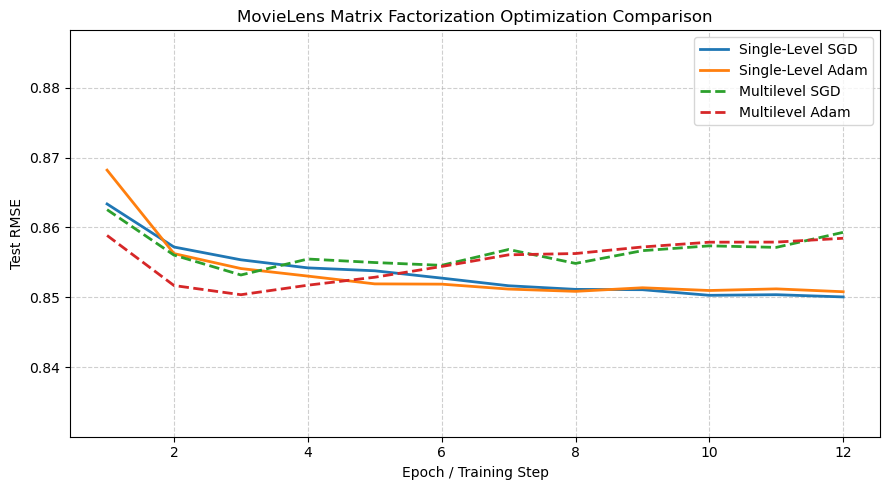

In [60]:
# Full Comparison: Single-Level vs Multilevel MF (No Baseline)

plt.figure(figsize=(9, 5))

models = [
    (sgd_test_rmse, "Single-Level SGD", "-"),
    (adam_test_rmse, "Single-Level Adam", "-"),
    (ml_sgd_test_rmse, "Multilevel SGD", "--"),
    (ml_adam_test_rmse, "Multilevel Adam", "--")
]

for rmse, label, style in models:
    plt.plot(
        range(1, len(rmse) + 1),
        rmse,
        linestyle=style,
        linewidth=2,
        label=label
    )

all_rmse = (
    sgd_test_rmse
    + adam_test_rmse
    + ml_sgd_test_rmse
    + ml_adam_test_rmse
)

plt.ylim(min(all_rmse) - 0.02, max(all_rmse) + 0.02)

plt.xlabel("Epoch / Training Step")
plt.ylabel("Test RMSE")
plt.title("MovieLens Matrix Factorization Optimization Comparison")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.savefig(
    movielens_fig_dir / "comparison_mf_rmse_plot_sgd_vs_adam_wGMP.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Summary 

The comparison plot shows that all four matrix factorization approaches converge to a narrow RMSE range between approximately 0.85 and 0.86, indicating similar recommendation performance across optimizers and training strategies. The largest reduction in prediction error occurs during the first few epochs, after which the curves flatten and exhibit only small fluctuations.

The single-level SGD and Adam models maintain the lowest and most stable test RMSE values in the later training stages, with both converging near 0.850. In contrast, the multilevel approaches initially follow similar trends but gradually drift slightly upward as the latent dimensionality increases, suggesting that additional model complexity provides limited improvement in generalization performance.

Adam demonstrates slightly faster early convergence, particularly in the multilevel setting, while SGD exhibits smoother long-term stability. The close alignment of all curves indicates that the sparse structure of the MovieLens data imposes a relatively consistent performance boundary across optimization methods.

#### FComparison table

In [61]:
# =Final MovieLens Comparison Results

comparison_results = pd.DataFrame({
    "Model": [
        "Global Mean Baseline",
        "SGD",
        "Adam",
        "Multilevel SGD",
        "Multilevel Adam"
    ],

    "Final Train RMSE": [
        np.nan,
        sgd_train_rmse[-1],
        adam_train_rmse[-1],
        ml_sgd_train_rmse[-1],
        ml_adam_train_rmse[-1]
    ],

    "Final Test RMSE": [
        test_rmse_baseline,
        sgd_test_rmse[-1],
        adam_test_rmse[-1],
        ml_sgd_test_rmse[-1],
        ml_adam_test_rmse[-1]
    ],

    "Runtime (seconds)": [
        np.nan,
        sgd_time,
        adam_time,
        ml_sgd_time,
        ml_adam_time
    ]
})

comparison_results = comparison_results.round(4)
comparison_results.to_csv(
    results_dir / "movielens" / "movielens_summary.csv",
    index=False
)

comparison_results

,Model,Final Train RMSE,Final Test RMSE,Runtime (seconds)
0,Global Mean Baseline,NaN,1.0355,NaN
1,SGD,0.5793,0.8501,120.9348
2,Adam,0.4792,0.8508,409.1822
3,Multilevel SGD,0.7161,0.8593,96.6596
4,Multilevel Adam,0.6366,0.8585,449.6955


#### Summary

The summary table shows that all matrix factorization models substantially outperform the Global Mean Baseline, reducing test RMSE from 1.0355 to approximately 0.85–0.86. This demonstrates the effectiveness of latent factor modeling in capturing personalized user–item interaction patterns within the sparse MovieLens dataset.

Among the single-level approaches, SGD achieves the lowest final test RMSE of 0.8501, while Adam attains a slightly lower training RMSE of 0.4792, indicating stronger optimization of the training data. Despite this more aggressive fitting behavior, Adam does not improve test performance relative to SGD, as both models converge to nearly identical predictive accuracy on unseen ratings.

The multilevel methods produce slightly higher test RMSE values compared to their single-level counterparts, with Multilevel SGD reaching 0.8593 and Multilevel Adam reaching 0.8585. Although multilevel training introduces progressive latent dimension expansion, the additional complexity does not translate into improved generalization performance. However, Multilevel SGD achieves the fastest runtime at approximately 49.53 seconds, while Adam-based methods require substantially more computational time, exceeding 228 seconds in both single-level and multilevel settings.

#### Runtime comparison plot

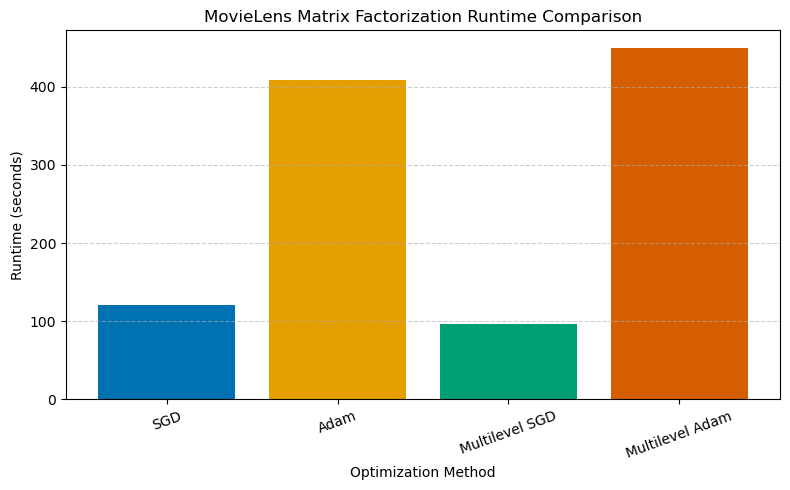

In [62]:
# Runtime Comparison for MovieLens Matrix Factorization

runtime_df = comparison_results.dropna(
    subset=["Runtime (seconds)"]
)

# Colorblind-safe palette
colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00"]

plt.figure(figsize=(8, 5))

plt.bar(
    runtime_df["Model"],
    runtime_df["Runtime (seconds)"],
    color=colors[:len(runtime_df)]
)

plt.xlabel("Optimization Method")
plt.ylabel("Runtime (seconds)")
plt.title("MovieLens Matrix Factorization Runtime Comparison")

plt.xticks(rotation=20)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.6
)

plt.tight_layout()

plt.savefig(
    movielens_fig_dir / "mf_runtime_plot_sgd_vs_adam.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Runtime Comparison (MovieLens)

The runtime comparison highlights a substantial difference in computational cost between SGD- and Adam-based optimization methods. Both SGD and Multilevel SGD complete training in approximately 50–55 seconds, making them significantly faster than the Adam-based approaches. The multilevel SGD model achieves the lowest runtime overall, indicating that progressive latent factor expansion can be implemented efficiently when combined with SGD optimization.

In contrast, Adam and Multilevel Adam require considerably longer training times, exceeding 228 seconds in both cases. This increased runtime reflects the additional computations associated with Adam’s adaptive moment estimation updates. While Adam achieves lower training RMSE values, the runtime increase is not accompanied by meaningful improvement in final test RMSE compared to SGD.

The relatively small runtime difference between the single-level and multilevel versions of each optimizer suggests that optimizer choice contributes more to computational cost than the multilevel structure itself. These results indicate that SGD provides a more computationally efficient optimization strategy for the sparse MovieLens recommendation setting while maintaining comparable predictive performance.